In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 

meds = pd.read_csv('medicine.csv')
meds.head(20)

,Age,Gender,Blood_Presure,Cholesterol,Ratio_Na_K,Medication
0,23,Female,High,High,25.355,meds5
1,47,Male,Low,High,13.093,meds3
2,47,Male,Low,High,10.114,meds3
3,28,Female,Normal,High,7.798,meds4
4,61,Female,Low,High,18.043,meds5
5,22,Female,Normal,High,8.607,meds4
6,49,Female,Normal,High,16.275,meds5
7,41,Male,Low,High,11.037,meds3
8,60,Male,Normal,High,15.171,meds5
9,43,Male,Low,Normal,19.368,meds5


In [7]:

meds.describe(include = "all")


,Age,Gender,Blood_Presure,Cholesterol,Ratio_Na_K,Medication
count,200.000000,200,200,200,200.000000,200
unique,NaN,2,3,2,NaN,5
top,NaN,Male,High,High,NaN,meds5
freq,NaN,104,77,103,NaN,91
mean,44.315000,NaN,NaN,NaN,16.084485,NaN
std,16.544315,NaN,NaN,NaN,7.223956,NaN
min,15.000000,NaN,NaN,NaN,6.269000,NaN
25%,31.000000,NaN,NaN,NaN,10.445500,NaN
50%,45.000000,NaN,NaN,NaN,13.936500,NaN
75%,58.000000,NaN,NaN,NaN,19.380000,NaN


In [8]:
meds.info()
meds.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            200 non-null    int64  
 1   Gender         200 non-null    object 
 2   Blood_Presure  200 non-null    object 
 3   Cholesterol    200 non-null    object 
 4   Ratio_Na_K     200 non-null    float64
 5   Medication     200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


Age              0
Gender           0
Blood_Presure    0
Cholesterol      0
Ratio_Na_K       0
Medication       0
dtype: int64

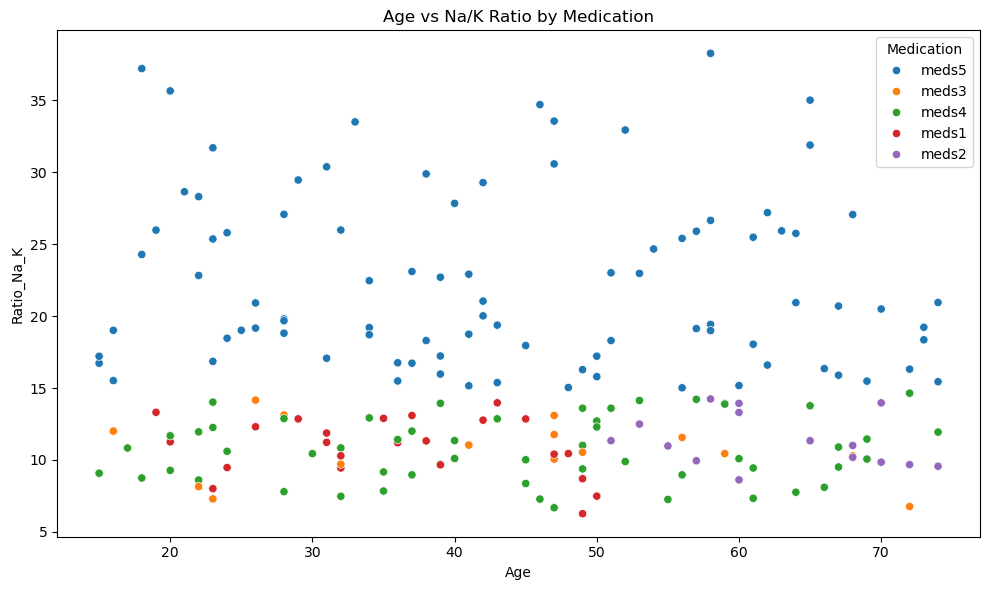

In [11]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=meds, x='Age', y='Ratio_Na_K', hue='Medication')
plt.title('Age vs Na/K Ratio by Medication')
plt.tight_layout()
plt.show()

In [14]:
meds['Medication'].value_counts()

Medication
meds5    91
meds4    54
meds1    23
meds3    16
meds2    16
Name: count, dtype: int64

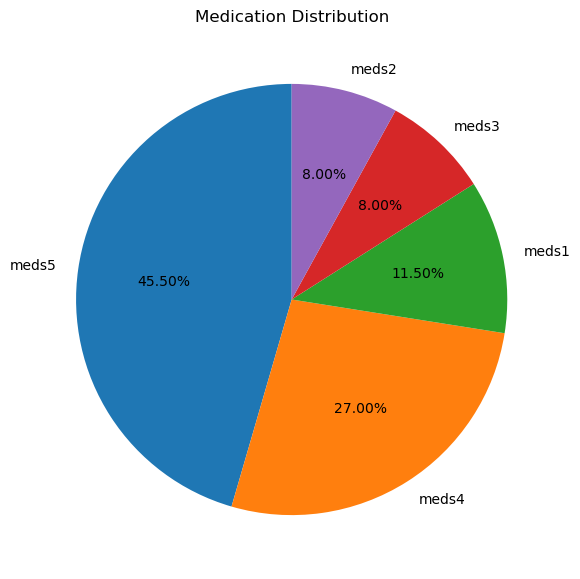

In [15]:
counts = meds['Medication'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(counts, labels=counts.index,
        autopct=lambda p: f'{p:.2f}%',
        startangle=90)
plt.title('Medication Distribution')
plt.show()

In [17]:
from sklearn.utils import resample

max_count = meds['Medication'].value_counts().max()
classes   = meds['Medication'].unique()

oversampled = []
for drug in classes:
    subset = meds[meds['Medication'] == drug]
    upsampled = resample(subset,
                          replace=True,
                          n_samples=max_count,
                          random_state=42)
    oversampled.append(upsampled)

meds_resampled = pd.concat(oversampled)
print(meds_resampled['Medication'].value_counts())

Medication
meds5    91
meds3    91
meds4    91
meds1    91
meds2    91
Name: count, dtype: int64


Medication
meds5    91
meds3    91
meds4    91
meds1    91
meds2    91
Name: count, dtype: int64


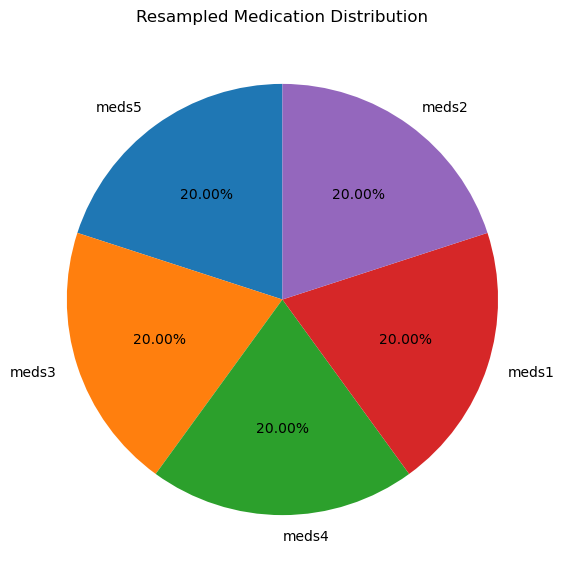

In [18]:
print(meds_resampled['Medication'].value_counts())

counts_r = meds_resampled['Medication'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(counts_r, labels=counts_r.index,
        autopct=lambda p: f'{p:.2f}%',
        startangle=90)
plt.title('Resampled Medication Distribution')
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

text_cols = meds_resampled.select_dtypes(include=['object']).columns.tolist()

for col in text_cols:
    unique_vals = meds_resampled[col].nunique()
    if unique_vals == 2:
        vals = meds_resampled[col].unique()
        meds_resampled[col] = meds_resampled[col].map({vals[0]: 0, vals[1]: 1})
        print(f"Binary encoded: '{col}' → {vals[0]}=0, {vals[1]}=1")
    elif unique_vals > 2:
        le = LabelEncoder()
        meds_resampled[col] = le.fit_transform(meds_resampled[col])
        print(f"Label encoded: '{col}' → {list(le.classes_)}")

meds_resampled.head()

,Age,Gender,Blood_Presure,Cholesterol,Ratio_Na_K,Medication
104,22,0,0,0,28.294,4
24,33,1,1,1,33.486,4
163,21,1,0,0,28.632,4
125,19,1,0,0,25.969,4
40,73,1,2,1,19.221,4


In [21]:
obj_cols = meds_resampled.select_dtypes(include=['object']).columns.tolist()
print("Remaining object columns:", obj_cols)
print(meds_resampled.dtypes)

Remaining object columns: []
Age                int64
Gender             int64
Blood_Presure      int64
Cholesterol        int64
Ratio_Na_K       float64
Medication         int64
dtype: object


Medication       1.000000
Blood_Presure    0.656666
Ratio_Na_K       0.538017
Gender           0.128120
Cholesterol      0.078613
Age              0.023827
Name: Medication, dtype: float64


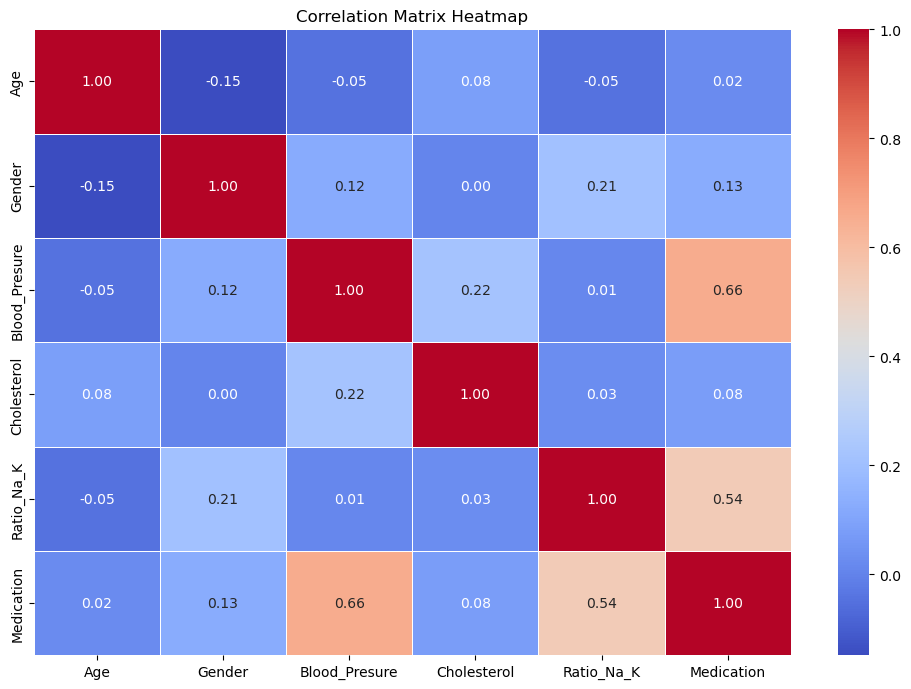

In [22]:
corr_matrix = meds_resampled.corr()
print(corr_matrix['Medication'].sort_values(ascending=False))

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

meds_resampled = meds_resampled.astype(
    {col: int for col in meds_resampled.select_dtypes('bool').columns}
)

X = meds_resampled.drop(columns=['Medication'])
y = meds_resampled['Medication']

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X shape: (455, 5)
y shape: (455,)
X_train shape: (364, 5)
X_test shape:  (91, 5)


In [25]:
def plot_learning_curve(model, name, X, y, cv):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, label='Training score', color='blue')
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, val_mean, label='CV score', color='orange')
    plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='orange')
    plt.title(f'Learning Curve — {name}')
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()


KNN (acc): 0.9121
KNN (f1):  0.9083
KNN ✓ done



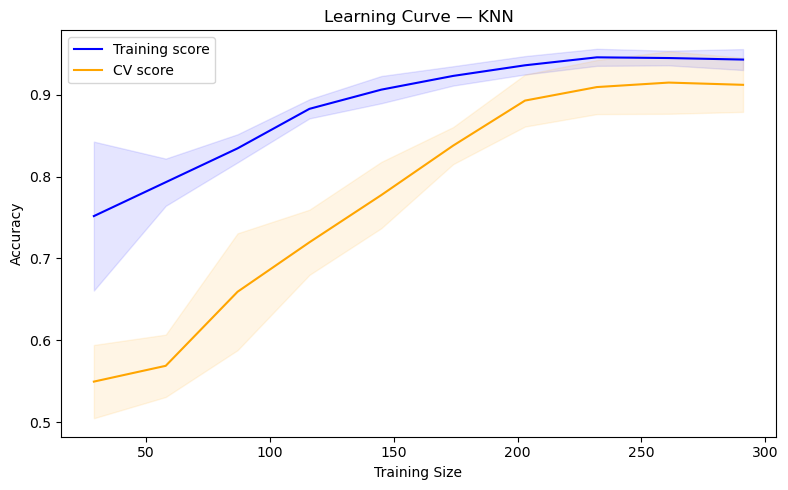

DT (acc): 0.9972
DT (f1):  0.9972
DT ✓ done



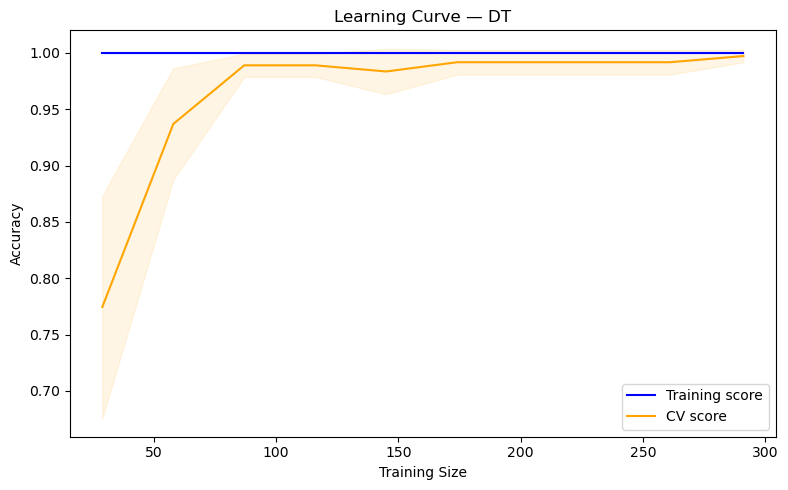

RF (acc): 0.9945
RF (f1):  0.9945
RF ✓ done



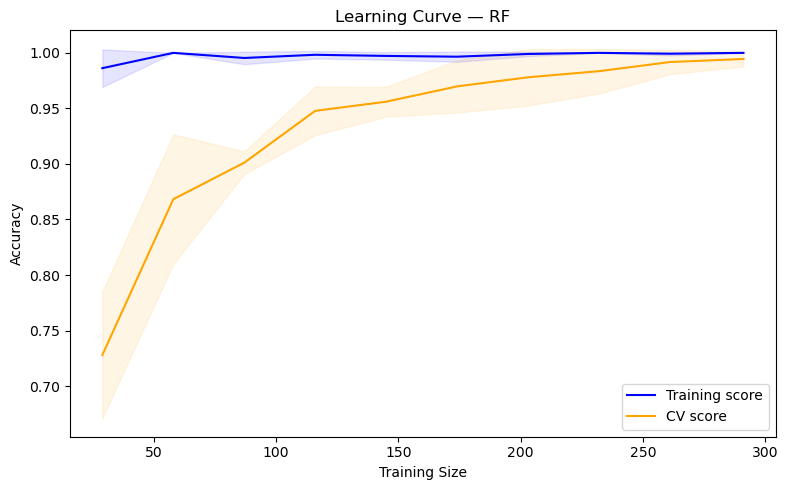

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score, learning_curve

models = [
    ('KNN', KNeighborsClassifier()),
    ('DT',  DecisionTreeClassifier()),
    ('RF',  RandomForestClassifier(n_estimators=5, random_state=42))
]

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
results_acc = []
results_f1  = []
names       = []


for name, model in models:
    acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
    f1_scores  = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='f1_weighted')
    results_acc.append(acc_scores)
    results_f1.append(f1_scores)
    names.append(name)
    print(f'{name} (acc): {acc_scores.mean():.4f}')
    print(f'{name} (f1):  {f1_scores.mean():.4f}')
    print(f'{name} ✓ done\n')
    plot_learning_curve(model, name, X_train_scaled, y_train, kfold)

Best model: DT (F1 = 0.9972)

Test Accuracy: 1.0000



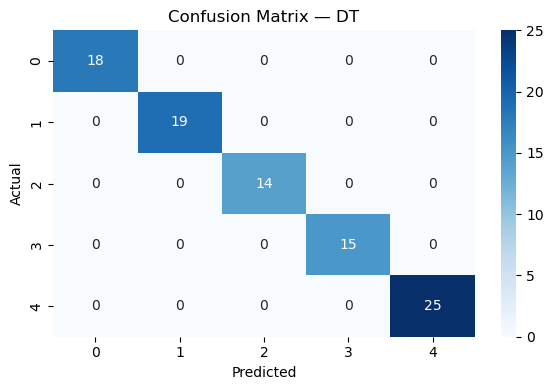

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        15
           4       1.00      1.00      1.00        25

    accuracy                           1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91



In [27]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

f1_means   = [scores.mean() for scores in results_f1]
best_index = f1_means.index(max(f1_means))
best_name  = names[best_index]
best_clf   = dict(models)[best_name]
print(f"Best model: {best_name} (F1 = {f1_means[best_index]:.4f})")

best_clf.fit(X_train_scaled, y_train)
y_pred = best_clf.predict(X_test_scaled)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))